<a href="https://colab.research.google.com/github/Taewan0508/RSI-Momentum_strat_backtest/blob/main/RSI_Momentum_strat_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-3614090860.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start= "2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


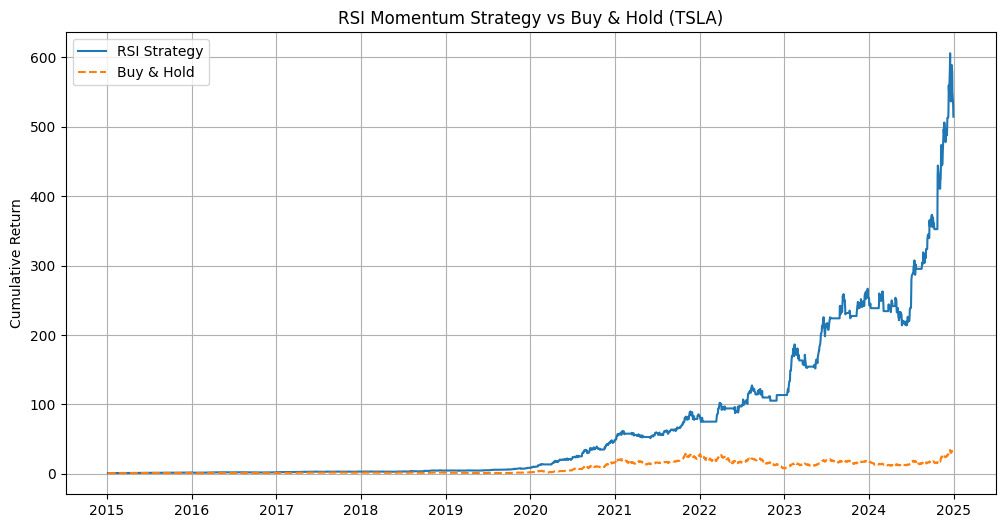

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

## Download Data
ticker = "TSLA"
data = yf.download(ticker, start= "2015-01-01", end="2025-01-01")
data = data[["Close"]].copy()
data = pd.DataFrame(data)
data.columns = ["Price"]

## Calculate RSI (14-Day)
delta = data["Price"].diff()

gain = delta.clip(lower = 0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
data["RSI"] = 100 - (100 / (1 + rs))

## Generate RSI Momentum Signals
data["Signal"] = 0
data.loc[data["RSI"] > 50, "Signal"] = 1
data.loc[data["RSI"] < 50, "Signal"] = 0

## Backtest with Stop-Loss and Take Profit
stop_loss = -0.05
take_profit = 0.10

position = 0
entry_price = 0
returns= []

for i in range(1, len(data)):
  price = data["Price"].iloc[i]
  prev_price = data["Price"].iloc[i-1]
  signal = data["Signal"].iloc[i]

  ## If not in a position, enter when signal is 1
  if position == 0 and signal == 1:
    position = 1
    entry_price = price

  ## If in a position, check stop-loss or take profit
  elif position == 1:
    change = (price - entry_price) / entry_price

    ## Stop-loss condition
    if change <= stop_loss:
      position = 0
      entry_price = 0

    ## Take-profit condition
    elif change >= take_profit:
      position = 0
      entry_price = 0

  ## If signal turns off, exit
  elif signal == 0:
    position = 0
    entry_price = 0

  ## Daily return (strategy return)
  daily_ret =  (price - prev_price) / prev_price
  returns.append(daily_ret * position)

## Align returns with original index
data = data.iloc[1:]
data["Strategy Return"] = returns
data["Cumulative Strategy"] = (1 + data["Strategy Return"]).cumprod()
data["Buy & Hold"] = (data["Price"] / data["Price"].iloc[0])

## Plot
plt.figure(figsize=(12, 6))
plt.plot(data["Cumulative Strategy"], label = "RSI Strategy")
plt.plot(data["Buy & Hold"], label="Buy & Hold", linestyle="--")
plt.title(f"RSI Momentum Strategy vs Buy & Hold ({ticker})")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()



